In [164]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os

import pandas as pd

import legwork as lw
import astropy.units as u
import numpy as np

import sys
sys.path.append("../helpers")

import initial_dists
from truncation import get_f_trunc
from sfh import SB15PhiCut
import gala.potential as gp
import cogsworth
import matplotlib.pyplot as plt
from scipy.integrate import quad

%config InlineBackend.figure_format = 'retina'

In [2]:
FOLDER = "/mnt/ceph/users/twagg/lisa-dcos/fiducial"
dco_type = "BHBH"

In [160]:
f_detects = []
pops = []

pop_files = []
f_det_files = []

for file in os.listdir(FOLDER):
    if file.startswith(f"{dco_type}_detectable"):
        pop_files.append(file)
    elif file.endswith(".npy"):
        f_det_files.append(file)

pop_files = np.sort(pop_files)
f_det_files = np.sort(f_det_files)

for i, (pop_file, f_det_file) in enumerate(zip(pop_files, f_det_files)):
    print(f"Loading {pop_file} and {f_det_file}")
    pops.append(cogsworth.pop.load(os.path.join(FOLDER, pop_file)))
    f_detects.append(np.load(os.path.join(FOLDER, f_det_file)))

Loading BHBH_detectable_0.h5 and BHBH_f_detect_0.npy
Loading BHBH_detectable_1.h5 and BHBH_f_detect_1.npy
Loading BHBH_detectable_10.h5 and BHBH_f_detect_10.npy
Loading BHBH_detectable_100.h5 and BHBH_f_detect_100.npy
Loading BHBH_detectable_101.h5 and BHBH_f_detect_101.npy
Loading BHBH_detectable_102.h5 and BHBH_f_detect_102.npy
Loading BHBH_detectable_103.h5 and BHBH_f_detect_103.npy
Loading BHBH_detectable_104.h5 and BHBH_f_detect_104.npy
Loading BHBH_detectable_105.h5 and BHBH_f_detect_105.npy
Loading BHBH_detectable_106.h5 and BHBH_f_detect_106.npy
Loading BHBH_detectable_107.h5 and BHBH_f_detect_107.npy
Loading BHBH_detectable_108.h5 and BHBH_f_detect_108.npy
Loading BHBH_detectable_109.h5 and BHBH_f_detect_109.npy
Loading BHBH_detectable_11.h5 and BHBH_f_detect_11.npy
Loading BHBH_detectable_110.h5 and BHBH_f_detect_110.npy
Loading BHBH_detectable_111.h5 and BHBH_f_detect_111.npy
Loading BHBH_detectable_112.h5 and BHBH_f_detect_112.npy
Loading BHBH_detectable_113.h5 and BHBH_f_d

In [161]:
for pop in pops:
    pop.final_pos, pop.final_vel
pop = cogsworth.pop.concat(*pops)

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


In [162]:
pop.initial_galaxy
sfh = cogsworth.sfh.StarFormationHistory()
for var in ["_x", "_y", "_z", "_v_x", "_v_y", "_v_z", "_tau", "_Z"]:
    setattr(sfh, var, getattr(pop.initial_galaxy, var))
pop._initial_galaxy = sfh

In [ ]:
sources = pop.to_legwork_sources(assume_mw_galactocentric=True)
sources.evolve_sources(t_evol=pop.initial_galaxy.tau)
sources.get_snr()

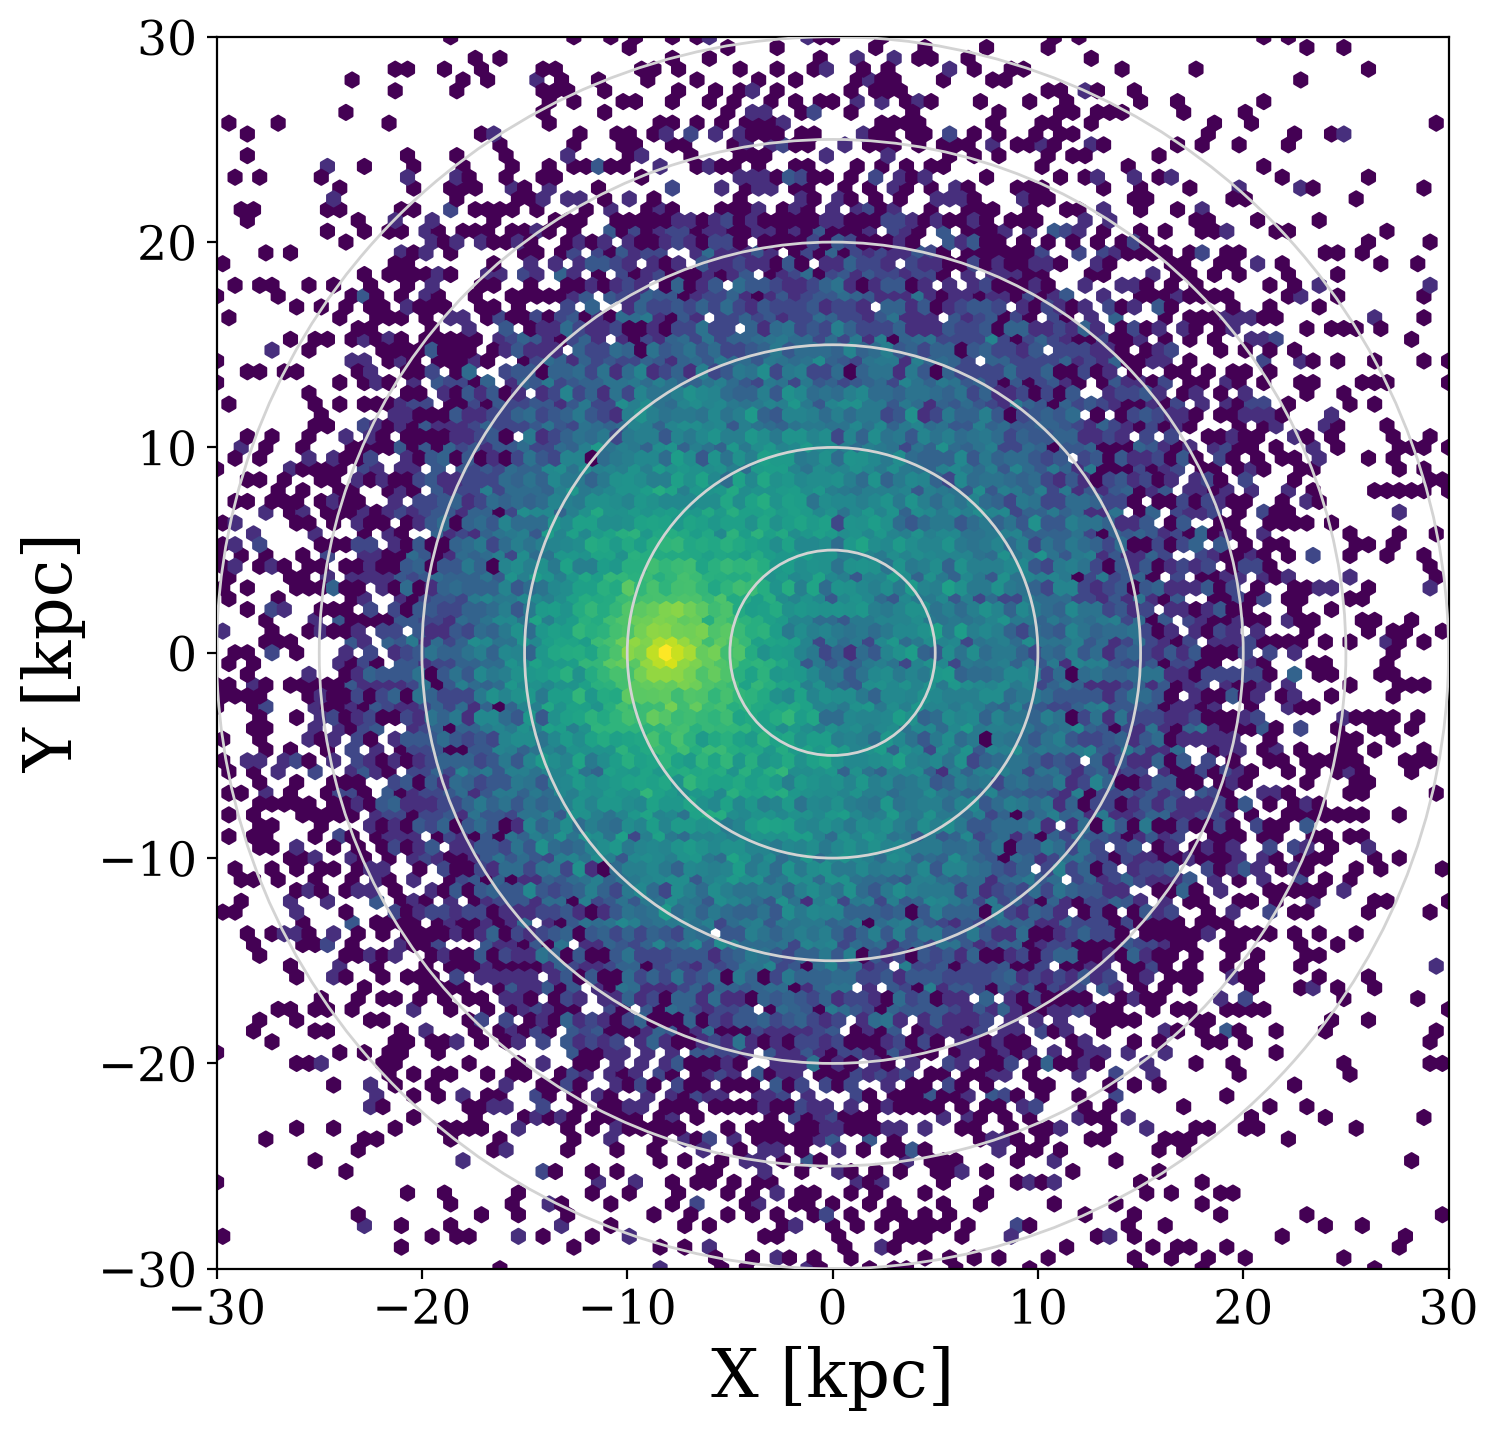

In [209]:
fig, ax = plt.subplots()
ax.hexbin(
    pop.final_pos[:, 0], pop.final_pos[:, 1], extent=(-30, 30, -30, 30), bins="log", gridsize=100
)

radii = [5, 10, 15, 20, 25, 30]
for r in radii:
    circle = plt.Circle((0, 0), r, color="lightgrey", fill=False, zorder=10)
    ax.add_artist(circle)

ax.set(
    xlim=(-30, 30), ylim=(-30, 30), xlabel="X [kpc]", ylabel="Y [kpc]",
    aspect="equal"
)
plt.show()

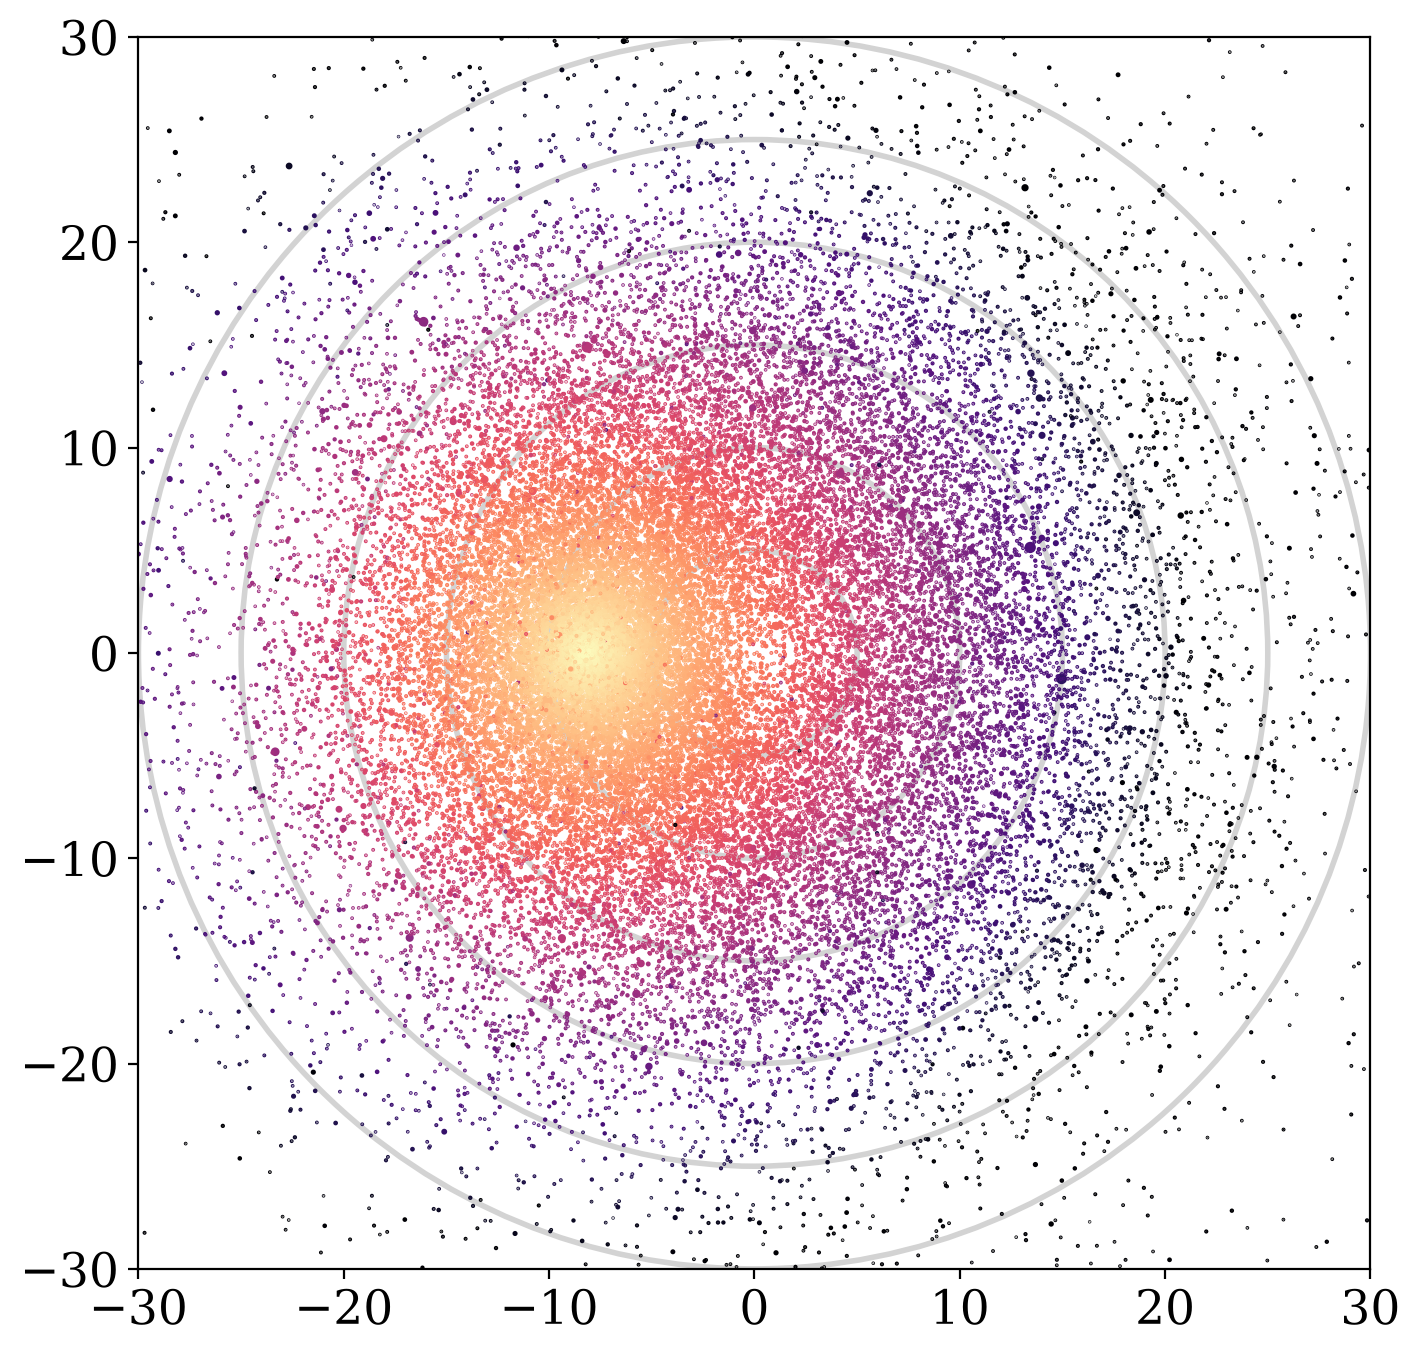

In [211]:
plt.scatter(pop.final_pos[:, 0], pop.final_pos[:, 1], s=5 * pop.initC["weights"], alpha=1, c=np.linalg.norm(pop.final_pos - [-8.2, 0, 0] * u.kpc, axis=1), cmap="magma_r", vmin=0, vmax=30, rasterized=True)

# add circles of constant radius, 1, 5, 10, 15, 20, 25, 30 kpc
radii = [5, 10, 15, 20, 25, 30]
for r in radii:
    circle = plt.Circle((0, 0), r, color="lightgrey", fill=False, zorder=-1, lw=2)
    plt.gca().add_artist(circle)

plt.xlim(-30, 30)
plt.ylim(-30, 30)
plt.gca().set_aspect("equal")

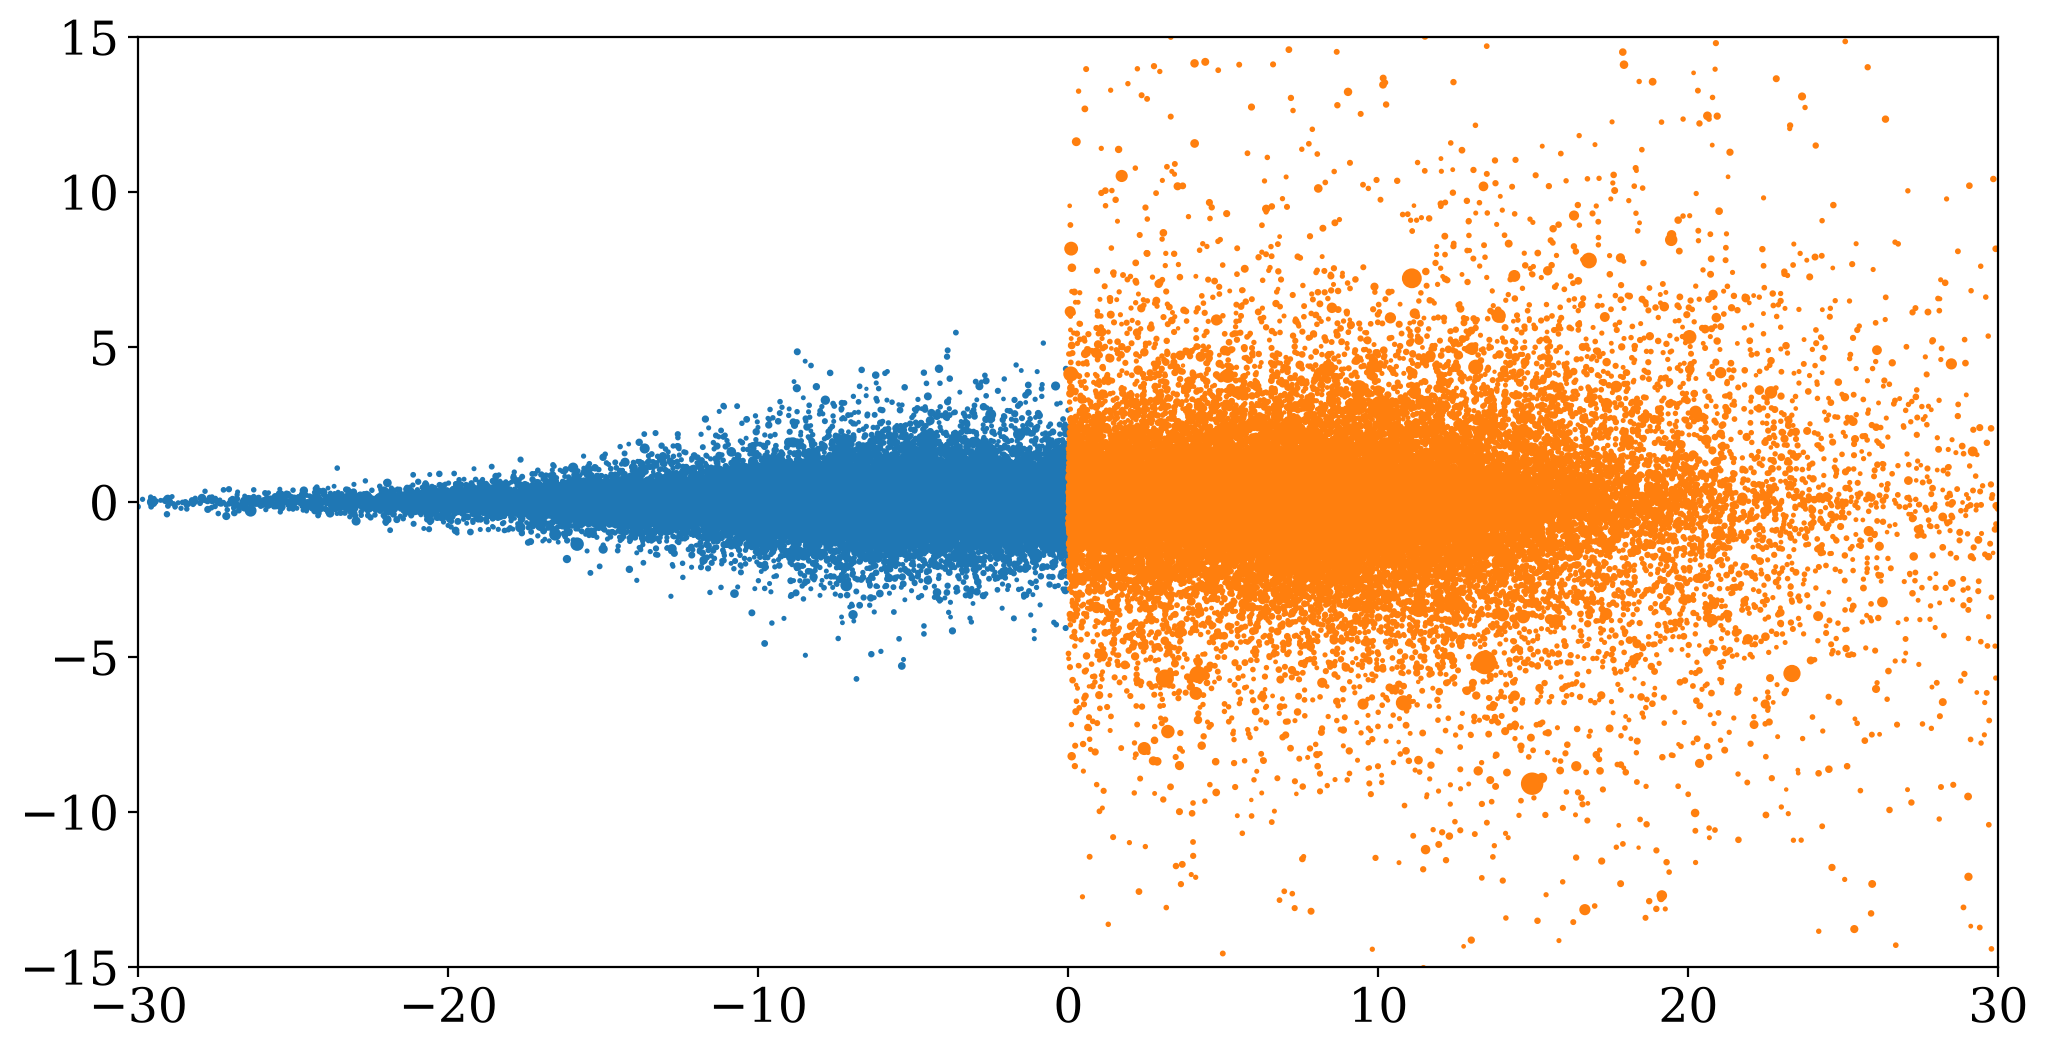

In [165]:
subset = np.random.choice(len(pop), p=pop.initC["weights"] / np.sum(pop.initC["weights"]), size=len(pop), replace=False)
S = 30

plt.scatter(-np.abs(pop.initial_galaxy.x[subset]), pop.initial_galaxy.z[subset], s=S * pop.initC["weights"].values[subset], alpha=1)
plt.scatter(np.abs(pop.final_pos[:, 0])[subset], pop.final_pos[:, 2][subset], s=S * pop.initC["weights"].values[subset], alpha=1)


plt.xlim(-30, 30)
plt.ylim(-15, 15)
plt.gca().set_aspect("equal")

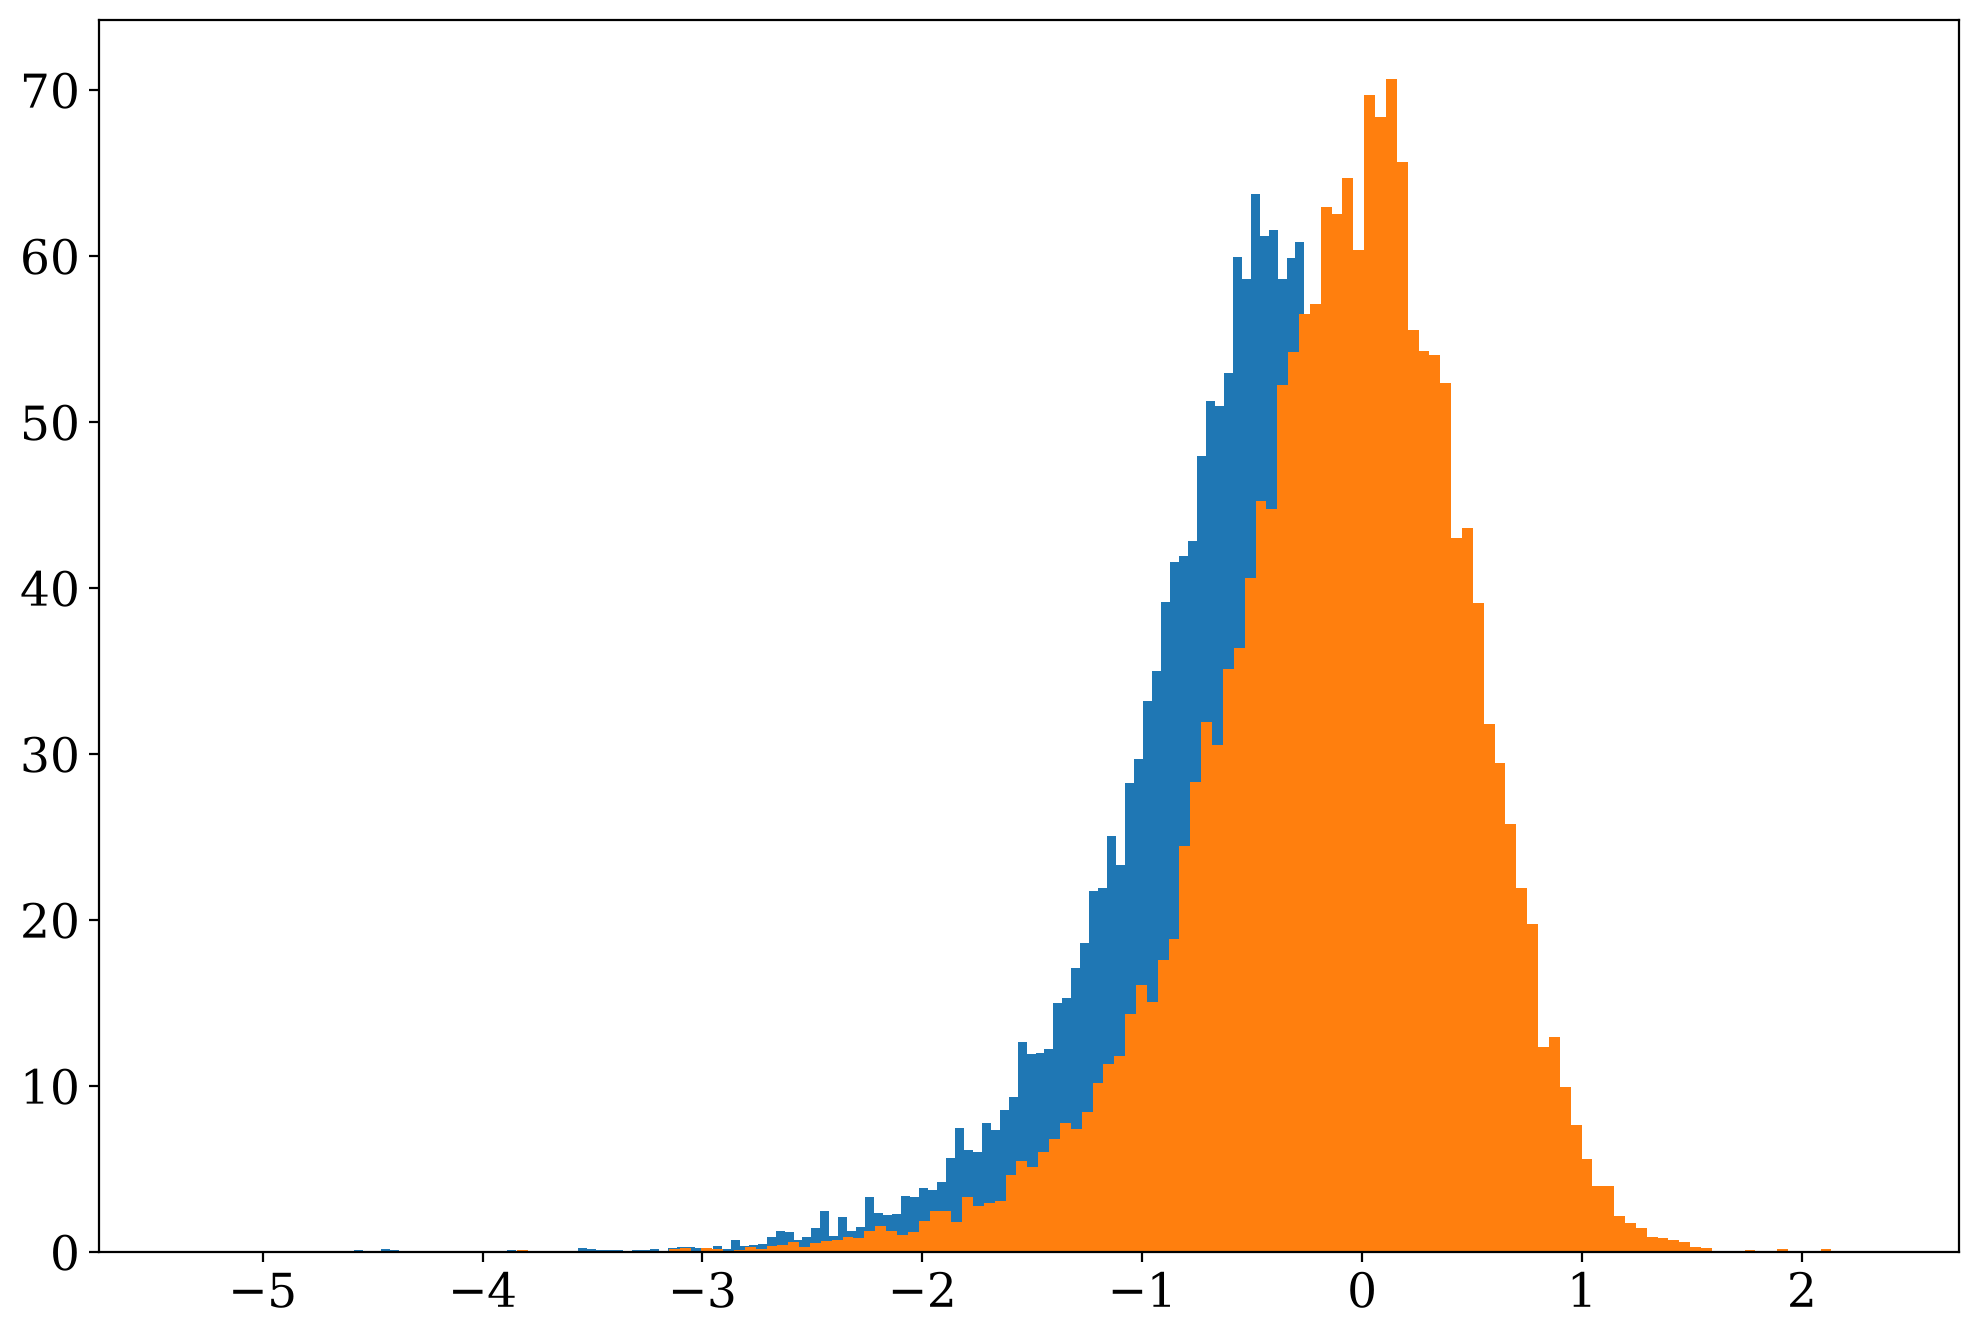

In [174]:
plt.hist(np.log10(np.abs(pop.initial_galaxy.z.value)), weights=pop.initC["weights"], bins=150);
plt.hist(np.log10(np.abs(pop.final_pos[:, 2].value)), weights=pop.initC["weights"], bins=150);

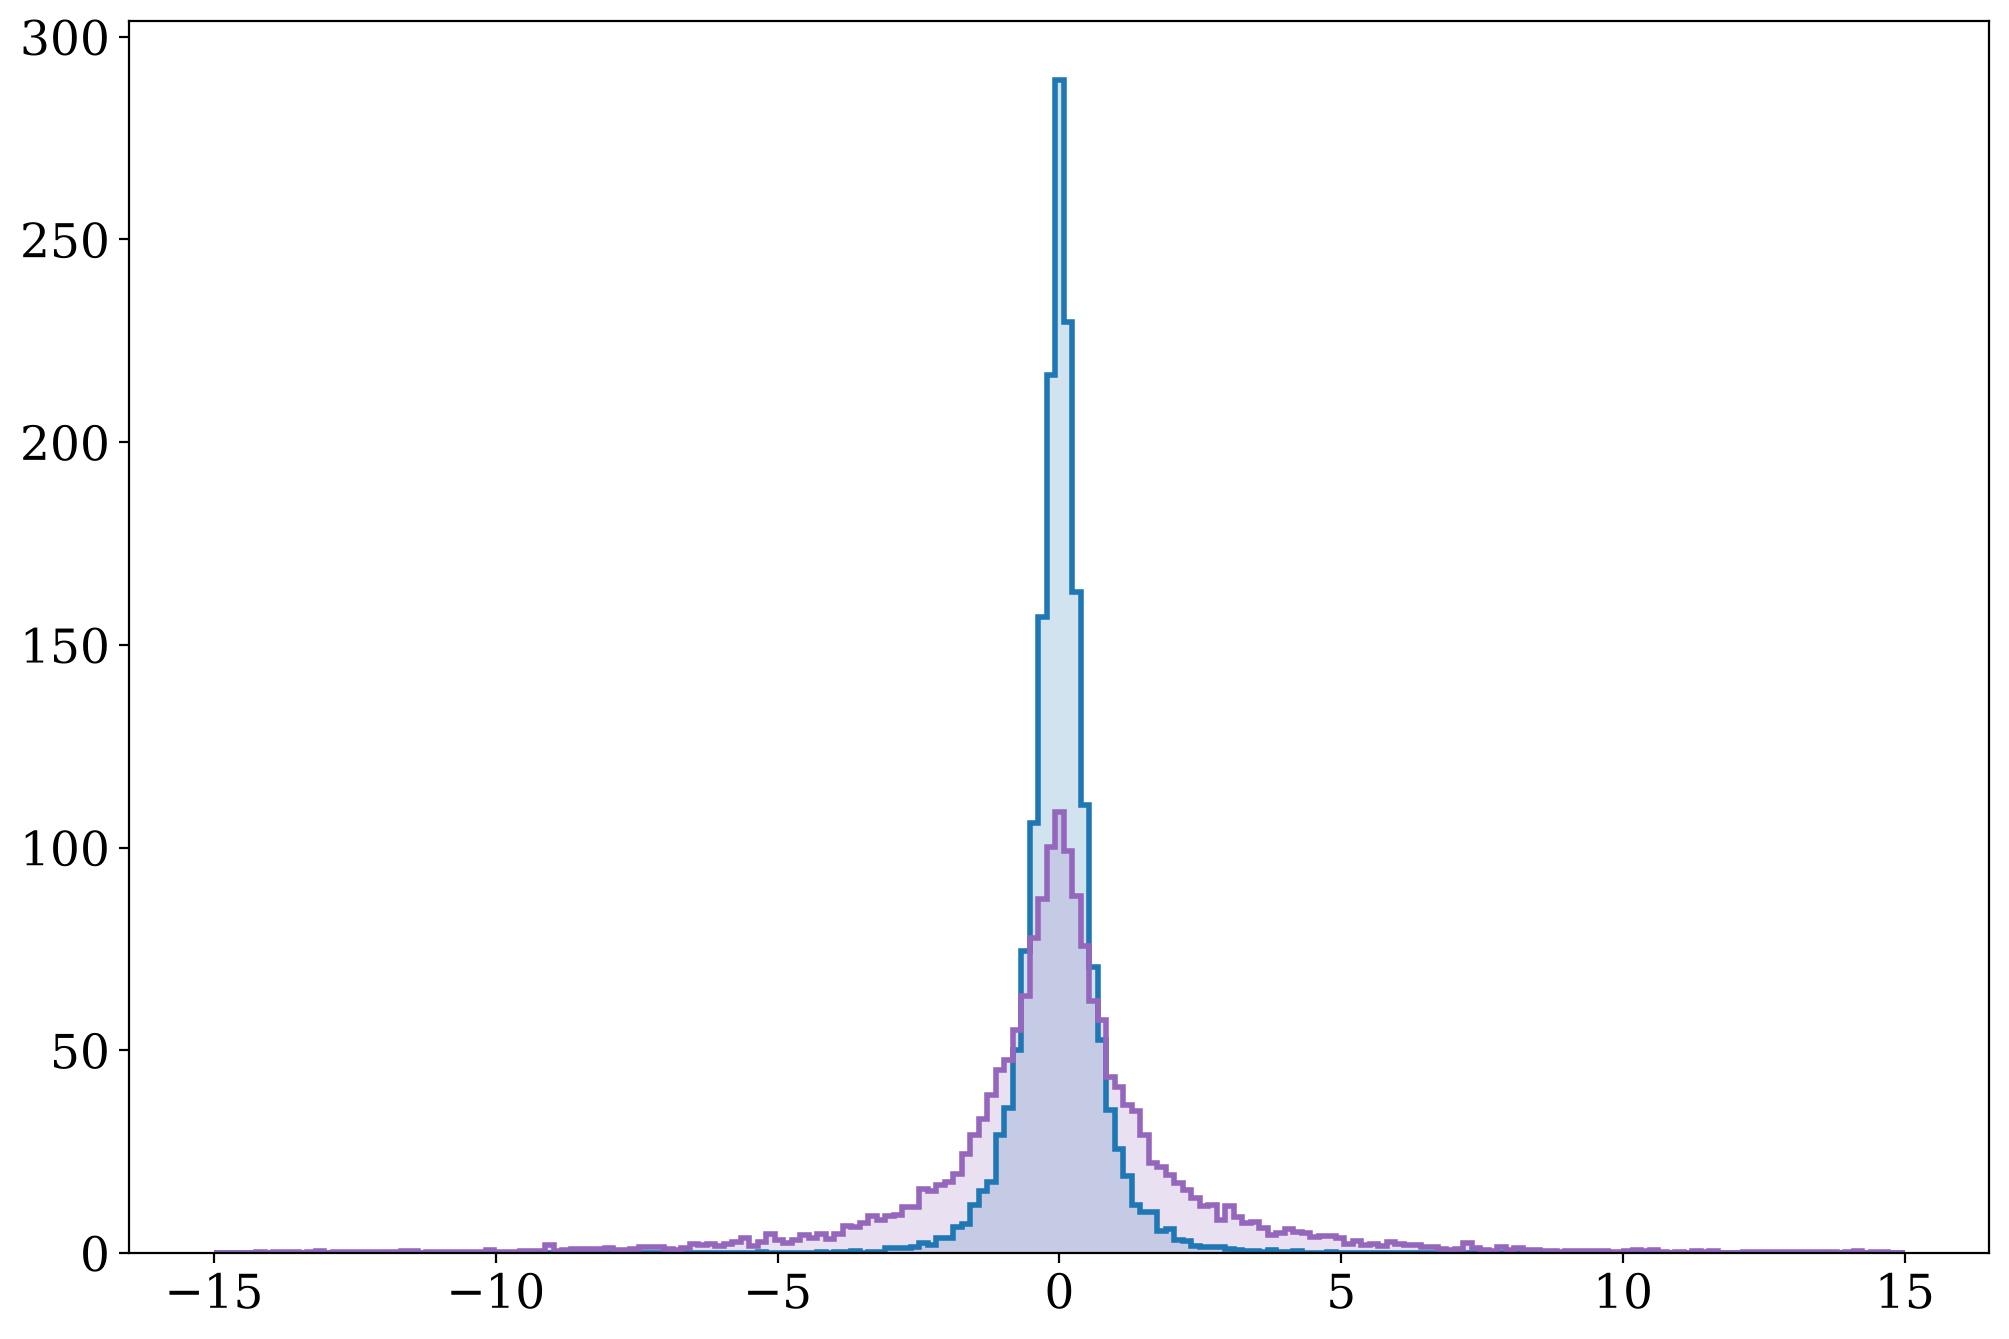

In [178]:
bins = np.linspace(-15, 15, 200)

plt.hist(pop.initial_galaxy.z.value, weights=pop.initC["weights"], bins=bins, histtype="step", lw=2);
plt.hist(pop.final_pos[:, 2].value, weights=pop.initC["weights"], bins=bins, histtype="step", lw=2, color="C4");
plt.hist(pop.initial_galaxy.z.value, weights=pop.initC["weights"], bins=bins, alpha=0.2, color="C0");
plt.hist(pop.final_pos[:, 2].value, weights=pop.initC["weights"], bins=bins, alpha=0.2, color="C4");
# plt.yscale("log")

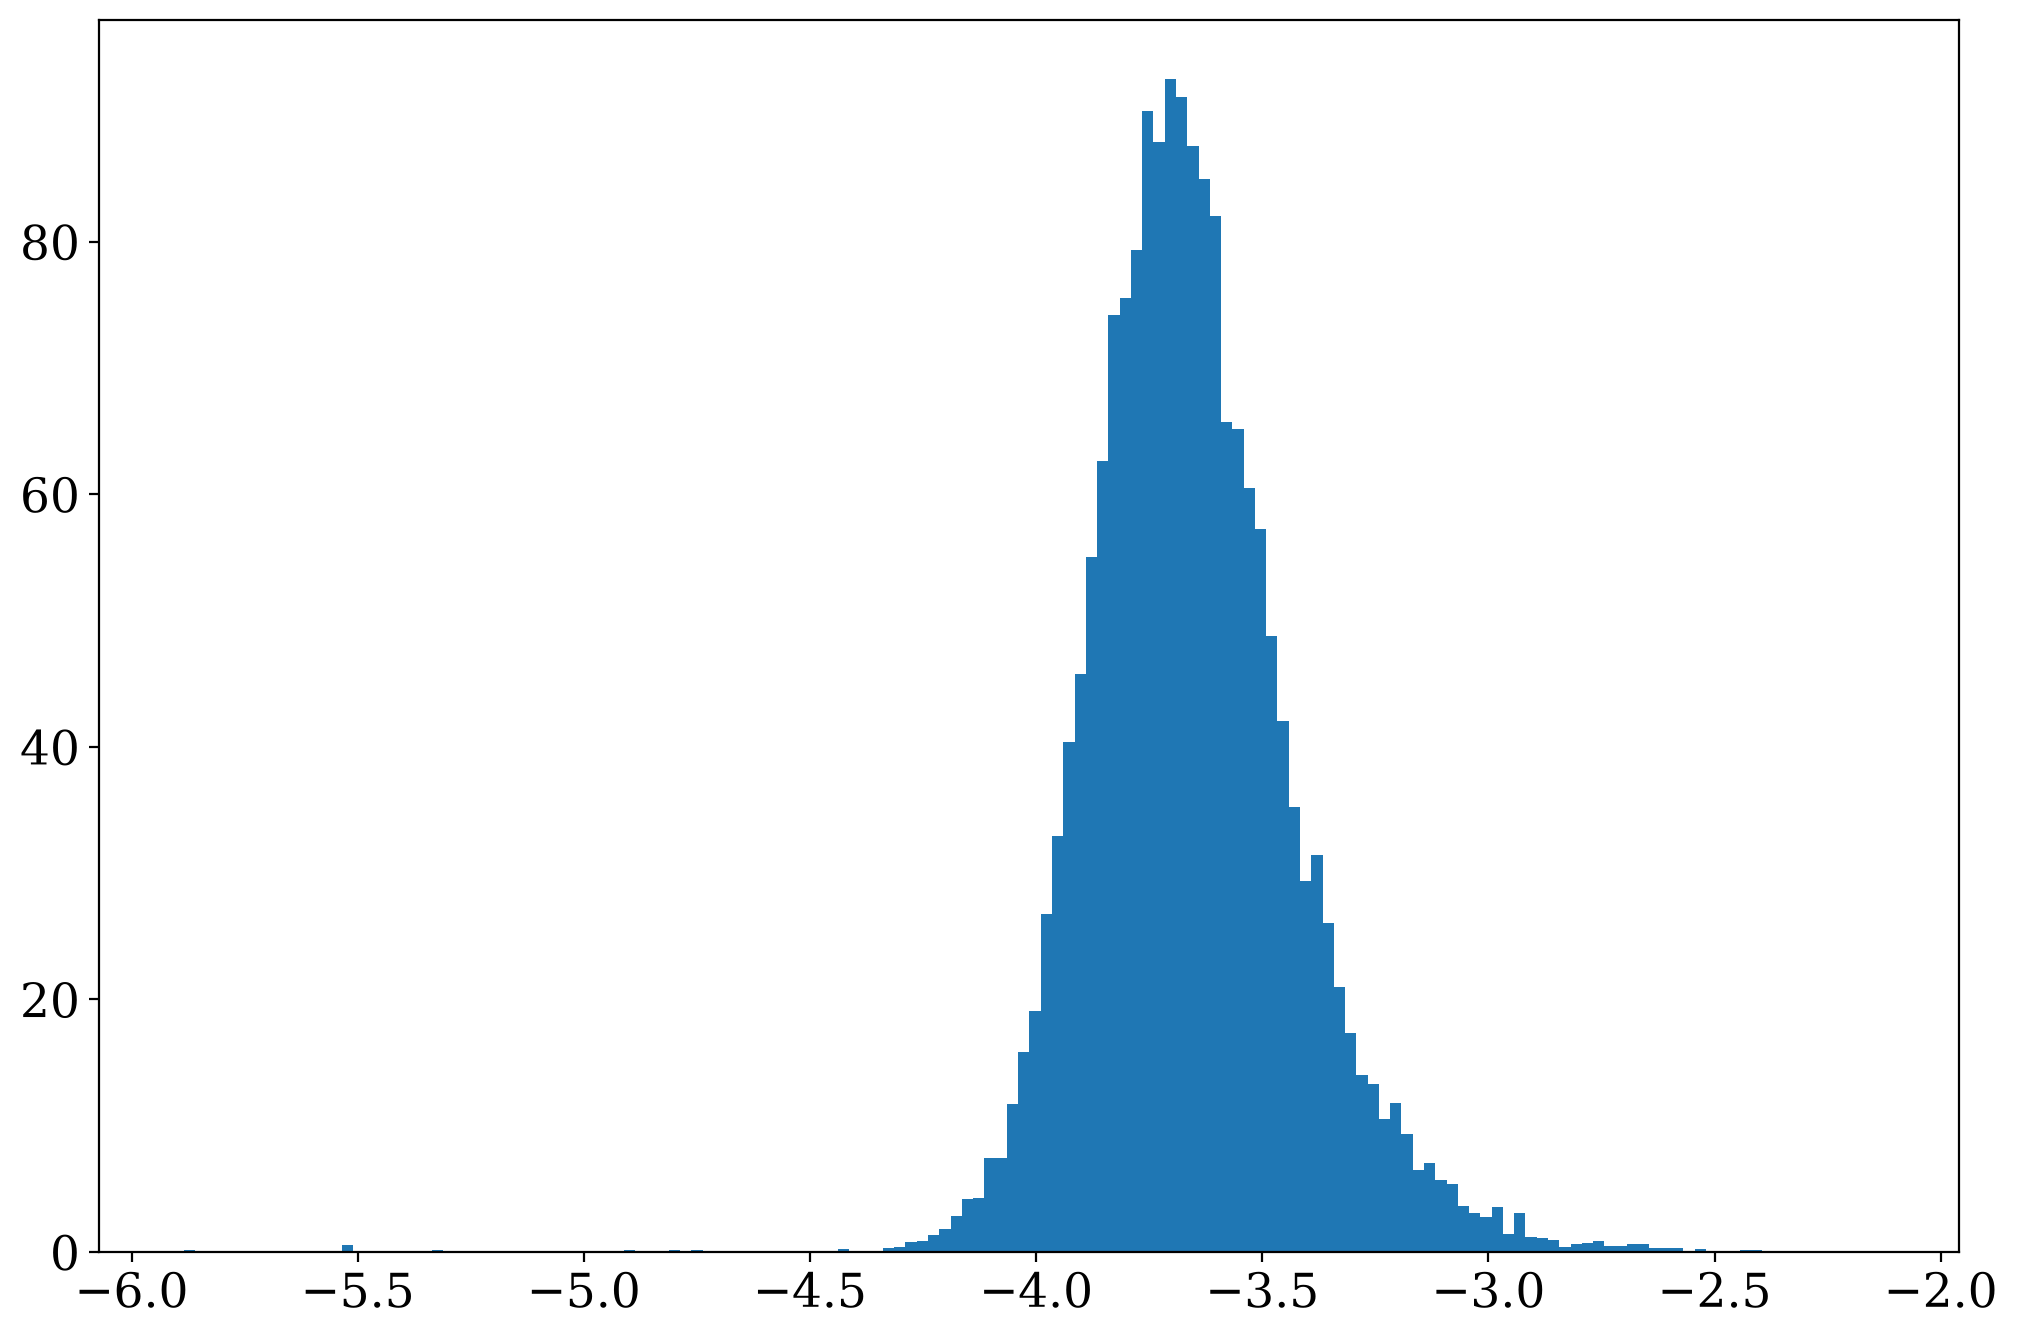

In [180]:
plt.hist(np.log10(sources.f_orb.value), weights=pop.initC["weights"], bins=150);

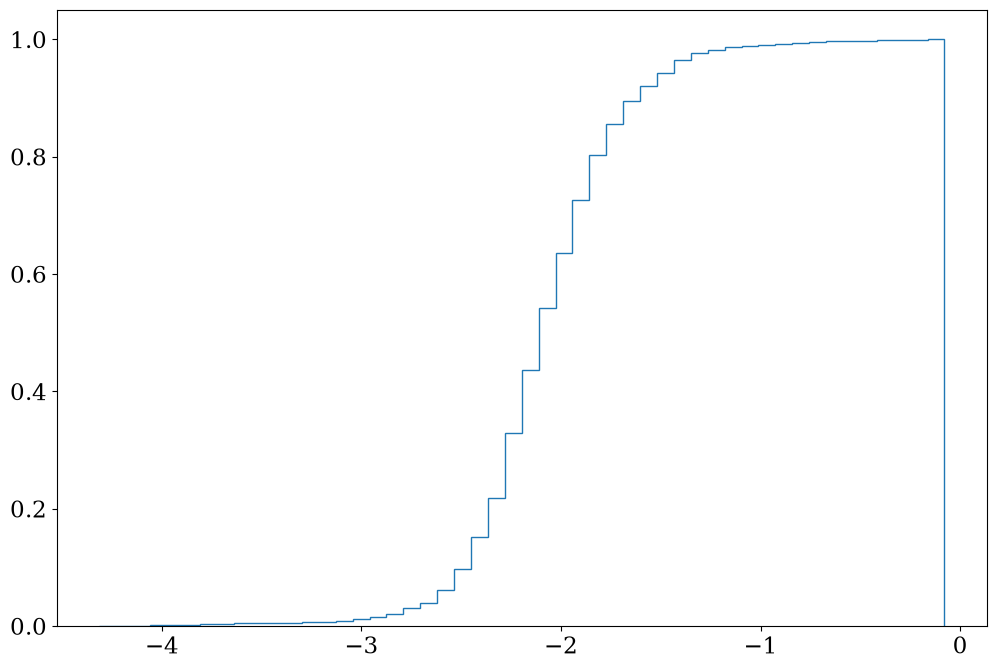

In [79]:
plt.hist(np.log10(sources.ecc), weights=pop.initC["weights"], bins=50, cumulative=True, density=True, histtype="step", label="Cumulative Distribution");

In [181]:
f_detect = np.concatenate(f_detects)

In [183]:
factor = 449911.4023285997 * 1.58

In [18]:
np.mean(f_detect), np.std(f_detect)

(np.float64(3.024649678858073e-05), np.float64(9.848023778181126e-06))

In [184]:
np.mean(f_detect), np.std(f_detect)

(np.float64(3.0720184932201237e-05), np.float64(1.1553520570153606e-05))

In [185]:
np.mean(f_detect) * factor, np.std(f_detect) * factor

(np.float64(21.837751142572113), np.float64(8.212935813649208))

(array([  3.,   7.,  15.,  38.,  55.,  77., 134., 141., 184., 210., 219.,
        199., 171., 178., 167., 128., 138.,  82.,  90.,  42.,  59.,  44.,
         35.,  25.,  25.,  12.,   9.,   8.,   9.,   7.,   6.,   2.,   2.,
          3.,   2.,   2.,   1.,   2.,   0.,   0.,   1.,   1.,   1.,   0.,
          0.,   1.,   0.,   0.,   0.,   2.,   2.,   0.,   0.,   0.,   1.,
          0.,   1.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   1.]),
 array([  4.3416027 ,   5.70164427,   7.06168583,   8.42172739,
          9.78176896,  11.14181052,  12.50185208,  13.86189364,
         15.22193521,  16.58197677,  17.94201833,  19.3020599 ,
         20.66210146,  22.02214302,  23.38218458,  24.74222615,
         26.10226771,  27.46230927,  28.82235084,  30.1823924 ,
         31.54243396,  32.90247552,  34.26251709,  35.62255865,
         36.98260021,  38.34264177,  39.70268334,  41.0627249 ,
         42.42276646,  43.78280803,  45.14284959,  46.50289115,
    

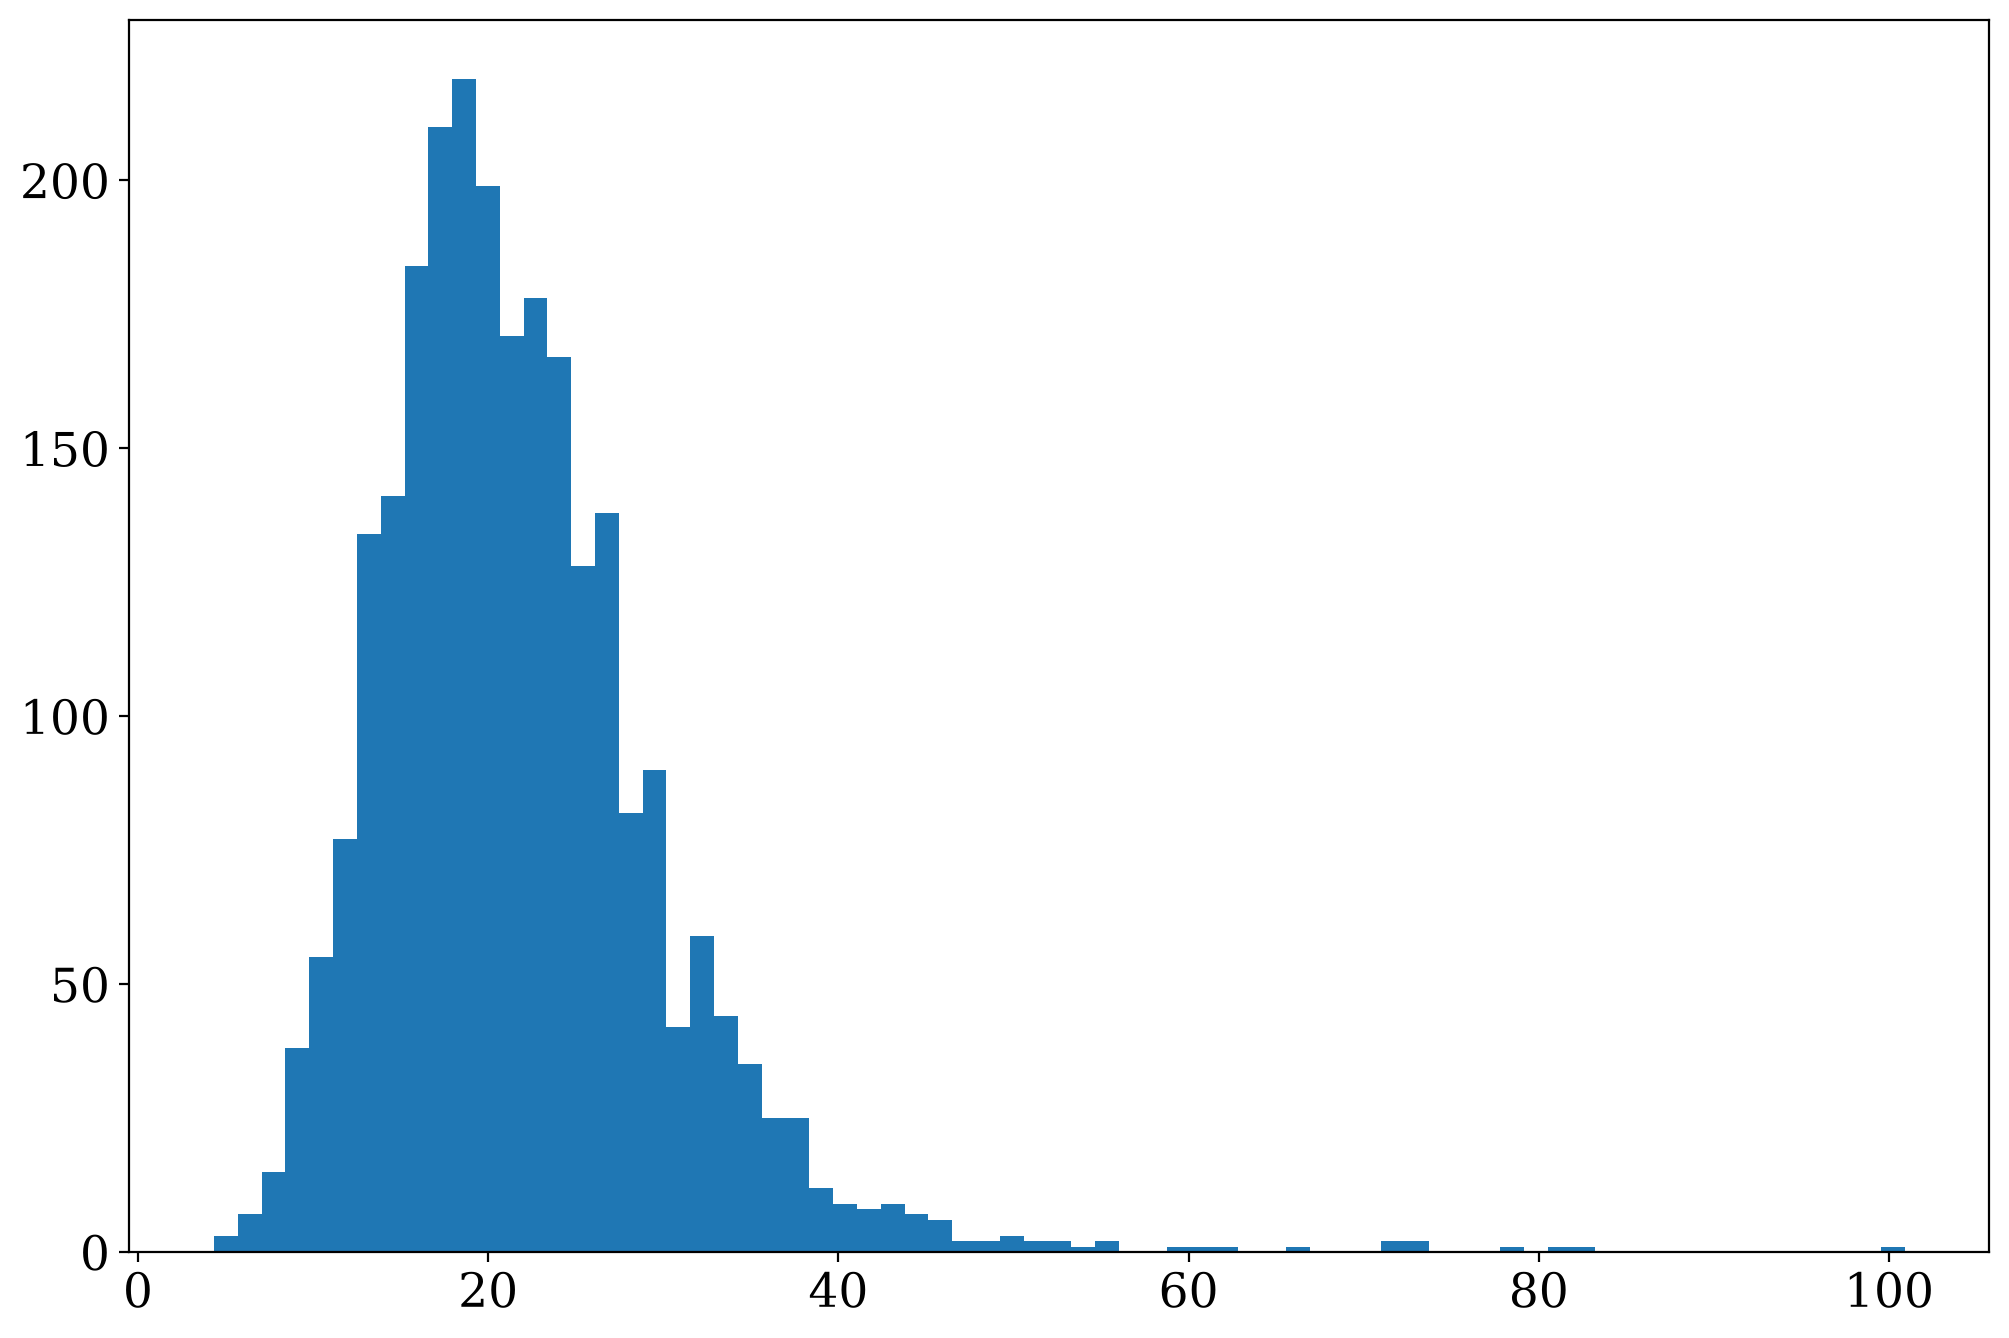

In [189]:
plt.hist(f_detect * factor, bins="auto")